<hr/>
<h1>5. Data Visualisation</h1>

<p>In this section, I will be conducting various Data Visualisations using my data set. I will be doing Univariate Analysis and also Bivariate Analysis. I will also be looking out for trends and relationships between Features. Data Visualisation is extremely important within my project as it will allow me to visually interpret my data set and notice trends or patterns that numbers otherwise may not be able to show or display.</p>

<hr/>
<h2>5.1 Univariate Analysis</h2>

<p>In this sub-section, I will be visualising each of the Time Series separately according to their variable. This will allow me to see the general trend and also evaluate the trends for each of the variable.</p>

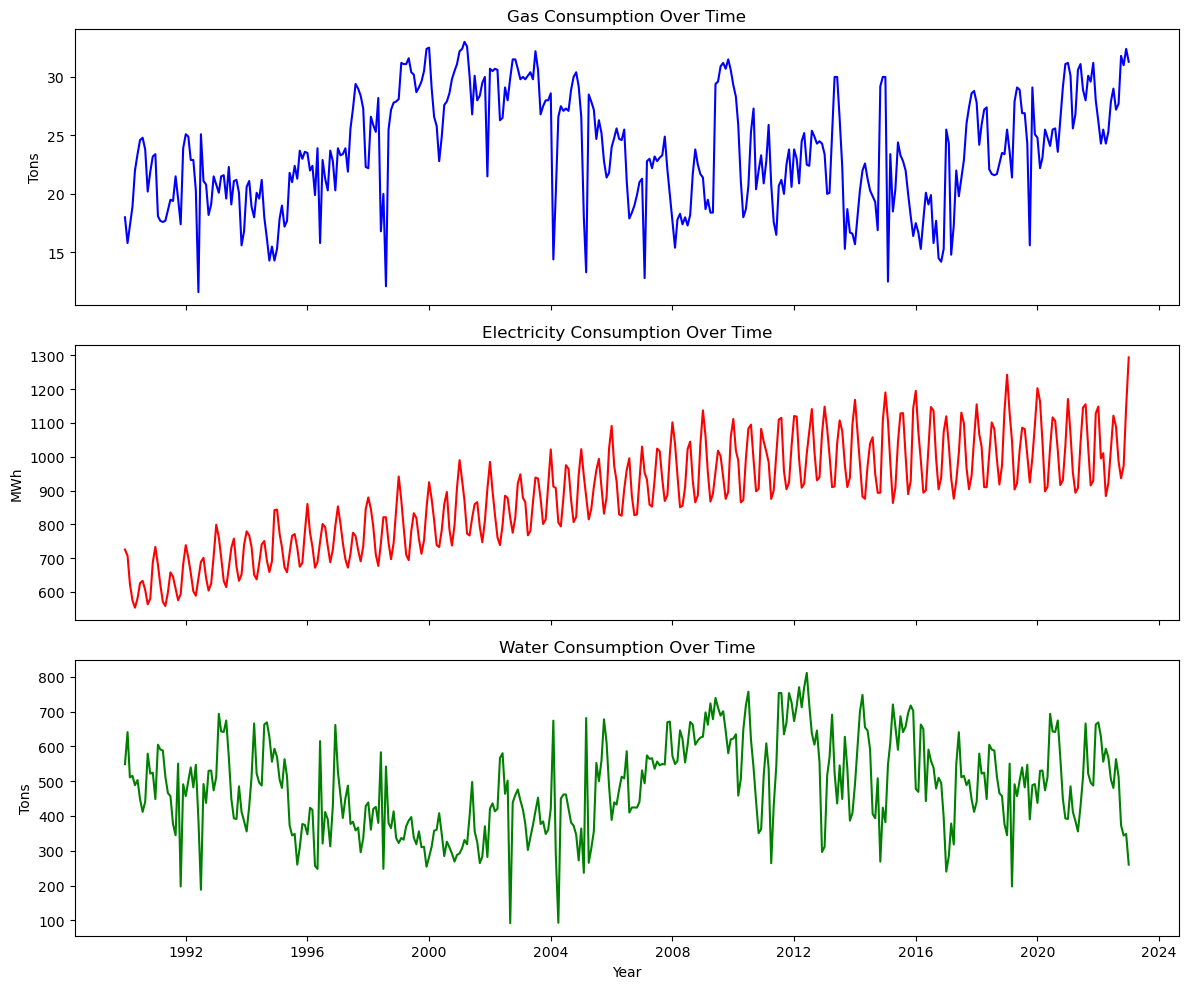

In [85]:
# ------------- Plotting Each Time Series Separately ------------- #
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ------------- Gas Consumption ------------- #
axes[0].plot(df.index, df["Gas Consumption (tons)"], color='blue')
axes[0].set_title("Gas Consumption Over Time")
axes[0].set_ylabel("Tons")

# ------------- Electricity Consumption ------------- #
axes[1].plot(df.index, df["Electricity Consumption (MWh)"], color='red')
axes[1].set_title("Electricity Consumption Over Time")
axes[1].set_ylabel("MWh")

# ------------- Water Consumption ------------- #
axes[2].plot(df.index, df["Water Consumption (tons)"], color='green')
axes[2].set_title("Water Consumption Over Time")
axes[2].set_ylabel("Tons")
axes[2].set_xlabel("Year")

# ------------- Displaying Plot ------------- #
plt.tight_layout()
plt.show()

<p>With reference to the Time Series above, I am able to make various observations for each of the Variable throughout the years. These observations are indicated below.</p>
<br/>
<p><strong><u>Gas Consumption</u></strong></p>
<ul>
    <li>The series fluctuates but stays within a certain range.</li>
    <li>There's no strong increasing or decreasing trend over time.</li>
    <li>The pattern appears repetitive, suggesting potential seasonality.</li>
</ul>
<p><strong><u>Electricity Consumption</u></strong></p>
<ul>
    <li>The data shows a clear increasing trend over time.</li>
    <li>Noticeable recurring cycles, indicating a seasonal pattern.</li>
    <li>As time progresses, variations become larger, possibly due to increased energy demand.</li>
</ul>
<p><strong><u>Water Consumption</u></strong></p>
<ul>
    <li>The time series is highly volatile, with large fluctuations.</li>
    <li>No obvious long-term increasing or decreasing trend.</li>
    <li>Some extreme values indicate potential outliers or irregular consumption patterns.</li>
    <li>Some cycles are visible but not as strong as electricity consumption.</li>
</ul>

<hr/>
<h2>5.2 Time Series Analysis</h2>

<p>Within the Time Series Analysis, I will be conducting the Augmented Dicky Fuller Test, Autocorrelation Analysis and Seasonal Decomposition. This will allow me to see which model is most suitable to be used for my dataset.</p>

<hr/>
<h2>5.2.1 Augmented Dicky Fuller Test (Stationarity Test)</h2>

<p>Before performing th ADF Test, I will be indicating the Hypothesis below and subsequently using the p-Value output by the cell below, I will either accept or reject the Status Quo on the 95% Confidence Interval as per industry standards.</p>
<br/>
<ul>
    <li>H0 (Status Quo Hypothesis): The time series is non-stationary and has a unit root.</li>
    <li>H1 (Alternative Hypothesis): The time series is stationary and has no unit root.</li>
</ul>
<br/>
<p>With the hypothesis listed out, I will be performing the ADF test in the cell below.</p>

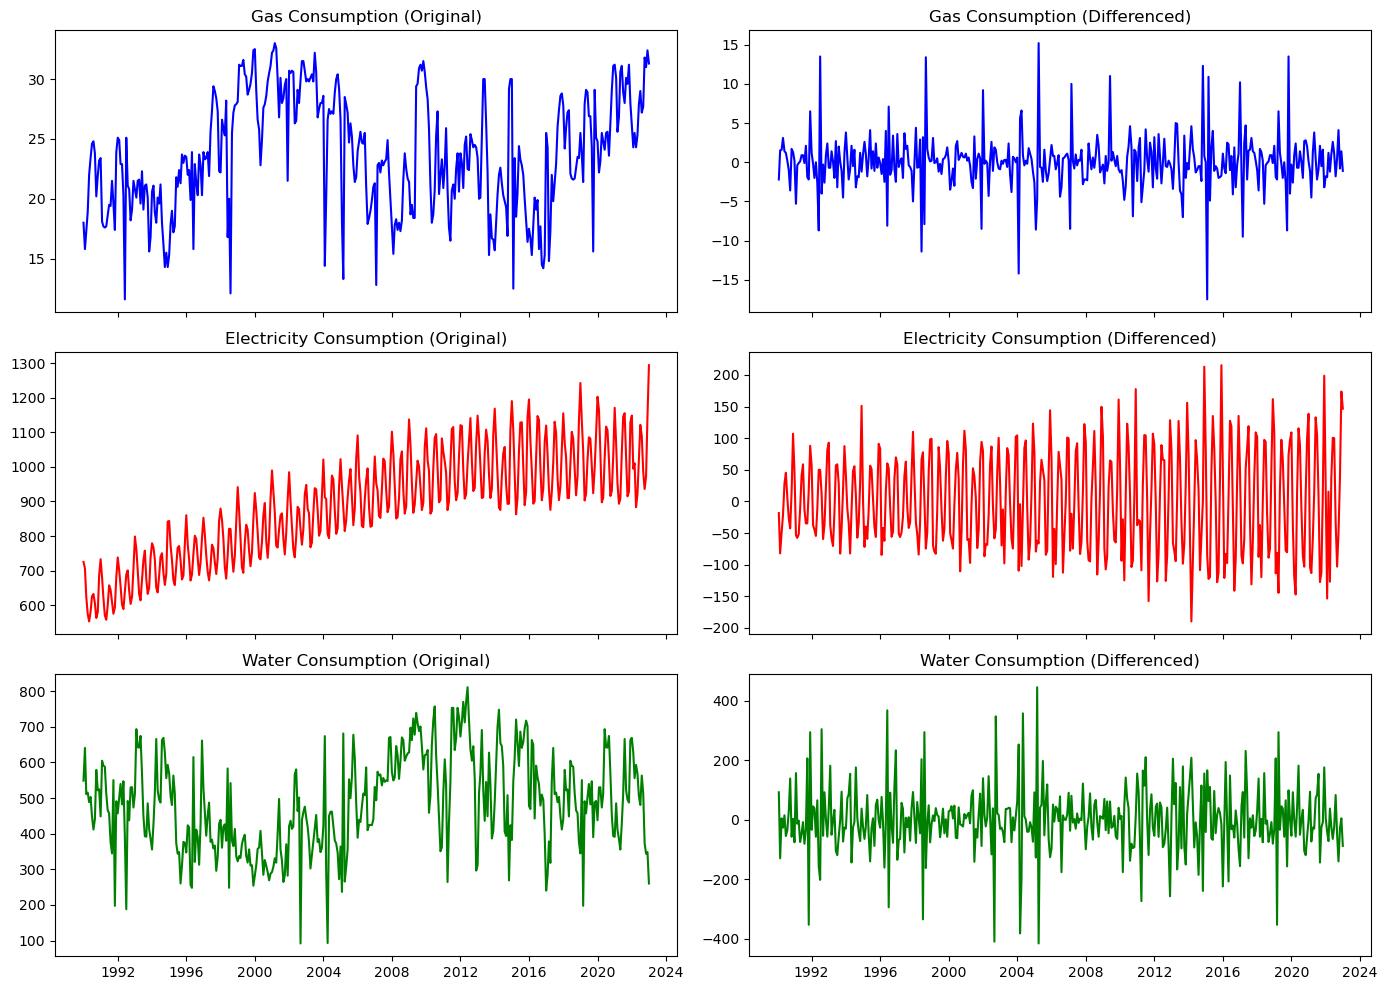

,p-value (Before Differencing),Stationary (Before Differencing),p-value (After Differencing),Stationary (After Differencing)
Variable,,,,
Gas Consumption,4.32e-03,True,1.94e-15,True
Electricity Consumption,1.67e-01,False,2.71e-08,True
Water Consumption,2.22e-04,True,1.50e-10,True


In [91]:
# ------------- Function To Perform ADF Test ------------- #
def adf_test(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        "Variable": label,
        "Test Statistic": result[0],
        "p-value": f"{result[1]:.2e}",  # Display in scientific notation
        "Stationary": result[1] < 0.05
    }

# ------------- Apply ADF Test On Original Data ------------- #
adf_results = {
    "Gas Consumption": adf_test(df["Gas Consumption (tons)"], "Gas Consumption"),
    "Electricity Consumption": adf_test(df["Electricity Consumption (MWh)"], "Electricity Consumption"),
    "Water Consumption": adf_test(df["Water Consumption (tons)"], "Water Consumption"),
}

# ------------- First-Order Differencing ------------- #
df["Gas Consumption Diff"] = df["Gas Consumption (tons)"].diff().dropna()
df["Electricity Consumption Diff"] = df["Electricity Consumption (MWh)"].diff().dropna()
df["Water Consumption Diff"] = df["Water Consumption (tons)"].diff().dropna()

# ------------- Apply ADF Test On Differenced Data ------------- #
adf_results_diff = {
    "Gas Consumption": adf_test(df["Gas Consumption Diff"], "Gas Consumption (Differenced)"),
    "Electricity Consumption": adf_test(df["Electricity Consumption Diff"], "Electricity Consumption (Differenced)"),
    "Water Consumption": adf_test(df["Water Consumption Diff"], "Water Consumption (Differenced)"),
}

# ------------- Create DataFrame For Comparison ------------- #
adf_comparison_df = pd.DataFrame({
    "Variable": adf_results.keys(),
    "p-value (Before Differencing)": [adf_results[var]["p-value"] for var in adf_results],
    "Stationary (Before Differencing)": [adf_results[var]["Stationary"] for var in adf_results],
    "p-value (After Differencing)": [adf_results_diff[var]["p-value"] for var in adf_results_diff],
    "Stationary (After Differencing)": [adf_results_diff[var]["Stationary"] for var in adf_results_diff],
}).set_index("Variable")

# ------------- Defining Subplots ------------- #
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)

# ------------- Original Time Series ------------- #
axes[0, 0].plot(df.index, df["Gas Consumption (tons)"], color='blue')
axes[0, 0].set_title("Gas Consumption (Original)")

axes[1, 0].plot(df.index, df["Electricity Consumption (MWh)"], color='red')
axes[1, 0].set_title("Electricity Consumption (Original)")

axes[2, 0].plot(df.index, df["Water Consumption (tons)"], color='green')
axes[2, 0].set_title("Water Consumption (Original)")

# ------------- Differenced Time Series (Drop NaNs for Plotting) ------------- #
axes[0, 1].plot(df.index[1:], df["Gas Consumption Diff"].dropna(), color='blue')
axes[0, 1].set_title("Gas Consumption (Differenced)")

axes[1, 1].plot(df.index[1:], df["Electricity Consumption Diff"].dropna(), color='red')
axes[1, 1].set_title("Electricity Consumption (Differenced)")

axes[2, 1].plot(df.index[1:], df["Water Consumption Diff"].dropna(), color='green')
axes[2, 1].set_title("Water Consumption (Differenced)")

# ------------- Displaying Plot ------------- #
plt.tight_layout()
plt.show()

# ------------- Removing Computed Data Columns ------------- #
df.drop(["Gas Consumption Diff", "Electricity Consumption Diff", "Water Consumption Diff"], axis=1, inplace=True)

# ------------- Displaying DataFrame ------------- #
adf_comparison_df.style.background_gradient(cmap="Blues")

<p>With reference to the output of the DataFrame with the p-Value above, I will be writing the statements for accepting or rejecting the Status Quo below.</p>
<br/>
<p><strong><u>Gas Consumption</u></strong></p>
<ul>
    <p><strong><u>Before Differencing</u></strong></p>
    <li>p-value = 0.00432 (less than 0.05)</li>
    <li>We reject the null hypothesis (H0) and conclude that the Gas Consumption time series is stationary.</li>
    <br/>
    <p><strong><u>After Differencing</u></strong></p>
    <li>p-value = 1.94e-15 (less than 0.05)</li>
    <li>We reject the null hypothesis (H0) and confirm that the Gas Consumption time series remains stationary after differencing.</li>
</ul>
<p><strong><u>Electricity Consumption</u></strong></p>
<ul>
    <p><strong><u>Before Differencing</u></strong></p>
    <li>p-value = 0.1668 (less than 0.05)</li>
    <li>We fail to reject the null hypothesis (H0) and conclude that the Electricity Consumption time series is non-stationary.</li>
    <br/>
    <p><strong><u>After Differencing</u></strong></p>
    <li>p-value = 2.71e-08 (less than 0.05)</li>
    <li>We reject the null hypothesis (H0) and conclude that the Electricity Consumption time series is now stationary after differencing.</li>
</ul>
<p><strong><u>Water Consumption</u></strong></p>
<ul>
    <p><strong><u>Before Differencing</u></strong></p>
    <li>p-value = 0.000222 (less than 0.05)</li>
    <li>We reject the null hypothesis (H0) and conclude that the Water Consumption time series is stationary.</li>
    <br/>
    <p><strong><u>After Differencing</u></strong></p>
    <li>p-value = 1.50e-10 (less than 0.05)</li>
    <li>We reject the null hypothesis (H0) and confirm that the Water Consumption time series remains stationary after differencing.</li>
</ul>
<br/>
<p>With the Accepting / Rejecting of the Status Quo indicated, I conclude the ADF Test and will move on to the next test.</p>

<hr/>
<h3>5.2.2 Seasonal Decomposition</h3>

<p>The Seasonal Decomposition is made up of a Sum of Product which consist of 3 main components which are Linear Trend, Seasonal Component and Random Residuals. I will be conducting the Seasonal Decomposition in the cell below and subsequently listing out the observations.</p>

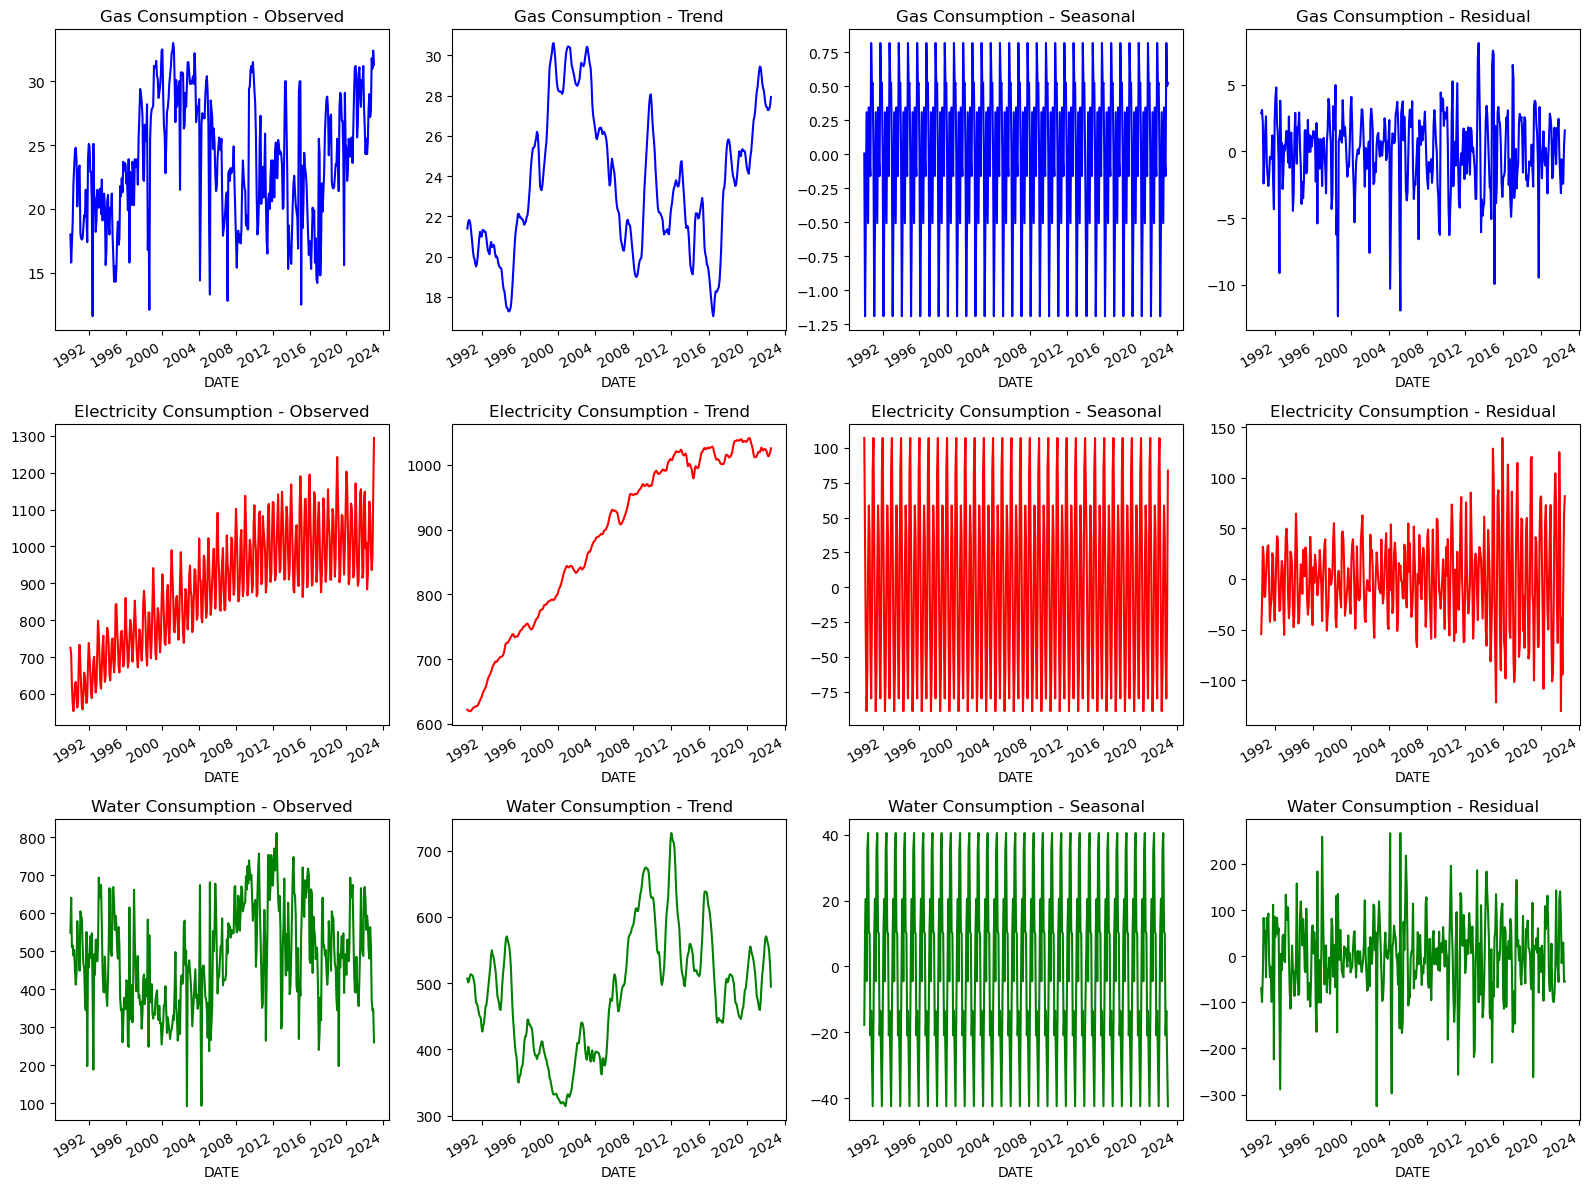

In [95]:
# ------------- Perform Seasonal Decomposition For Each Time Series ------------- #
decomposition_gas = seasonal_decompose(df["Gas Consumption (tons)"], model='additive', period=12)
decomposition_electricity = seasonal_decompose(df["Electricity Consumption (MWh)"], model='additive', period=12)
decomposition_water = seasonal_decompose(df["Water Consumption (tons)"], model='additive', period=12)

# ------------- Defining Subplots ------------- #
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# ------------- Function To Plot Decomposition Components WitH Colors ------------- #
def plot_decomposition(decomposition, ax_row, title, color):
    decomposition.observed.plot(ax=axes[ax_row, 0], title=f"{title} - Observed", color=color)
    decomposition.trend.plot(ax=axes[ax_row, 1], title=f"{title} - Trend", color=color)
    decomposition.seasonal.plot(ax=axes[ax_row, 2], title=f"{title} - Seasonal", color=color)
    decomposition.resid.plot(ax=axes[ax_row, 3], title=f"{title} - Residual", color=color)

# ------------- Ploting All Three Time Series Decompositions ------------- #
plot_decomposition(decomposition_gas, 0, "Gas Consumption", "blue")
plot_decomposition(decomposition_electricity, 1, "Electricity Consumption", "red")
plot_decomposition(decomposition_water, 2, "Water Consumption", "green")

# ------------- Displaying Plot ------------- #
plt.tight_layout()
plt.show()

<p>With reference to the output of the Seasonal Decomposition Time Series Analysis above, I will be indcating my observations from the output below.</p>
<br/>
<p><strong><u>Gas Consumption</u></strong></p>
<ul>
    <li>Observed: Fluctuates over time but does not show a strong upward or downward trend.</li>
    <li>Trend: Shows phases of increase and decrease, indicating cyclical patterns rather than a constant rise or fall.</li>
    <li>Seasonality: Regular patterns are present, but the magnitude is small compared to Electricity and Water Consumption.</li>
    <li>Residuals: Some fluctuations remain, but they appear random, suggesting that the model captures most of the trend and seasonality.</li>
</ul>
<p><strong><u>Electricity Consumption</u></strong></p>
<ul>
    <li>Observed: Clear upward trend over time, indicating increased electricity demand.</li>
    <li>Trend: Strong increasing trend, with occasional slowdowns but no major decline.</li>
    <li>Seasonality: Well-defined, repeating cycles, likely following annual or monthly patterns.</li>
    <li>Residuals: Higher volatility compared to Gas Consumption, suggesting external factors influencing electricity usage.</li>
</ul>
<p><strong><u>Water Consumption</u></strong></p>
<ul>
    <li>Observed: More fluctuations and higher volatility compared to Gas and Electricity.</li>
    <li>Trend: Shows cycles of rising and falling consumption, rather than a consistent trend.</li>
    <li>Seasonality: Noticeable recurring patterns, but less regular compared to Electricity.</li>
    <li>Residuals: Large variability, indicating that external unpredictable factors impact water consumption significantly.</li>
</ul>
<br/>
<p>With all the observations indicated, I conclude the Seasonal Decomposition and will proceed with Autocorrelation Analysis.</p>

<hr/>
<h3>5.2.3 Autocorrelation Analysis</h3>

<p>The Autocorrelation Test is used to analyze how a time series correlates with its past values (lags). It helps identify patterns, trends, and seasonality in the data, which is crucial for selecting appropriate ARIMA/SARIMA parameters.</p>

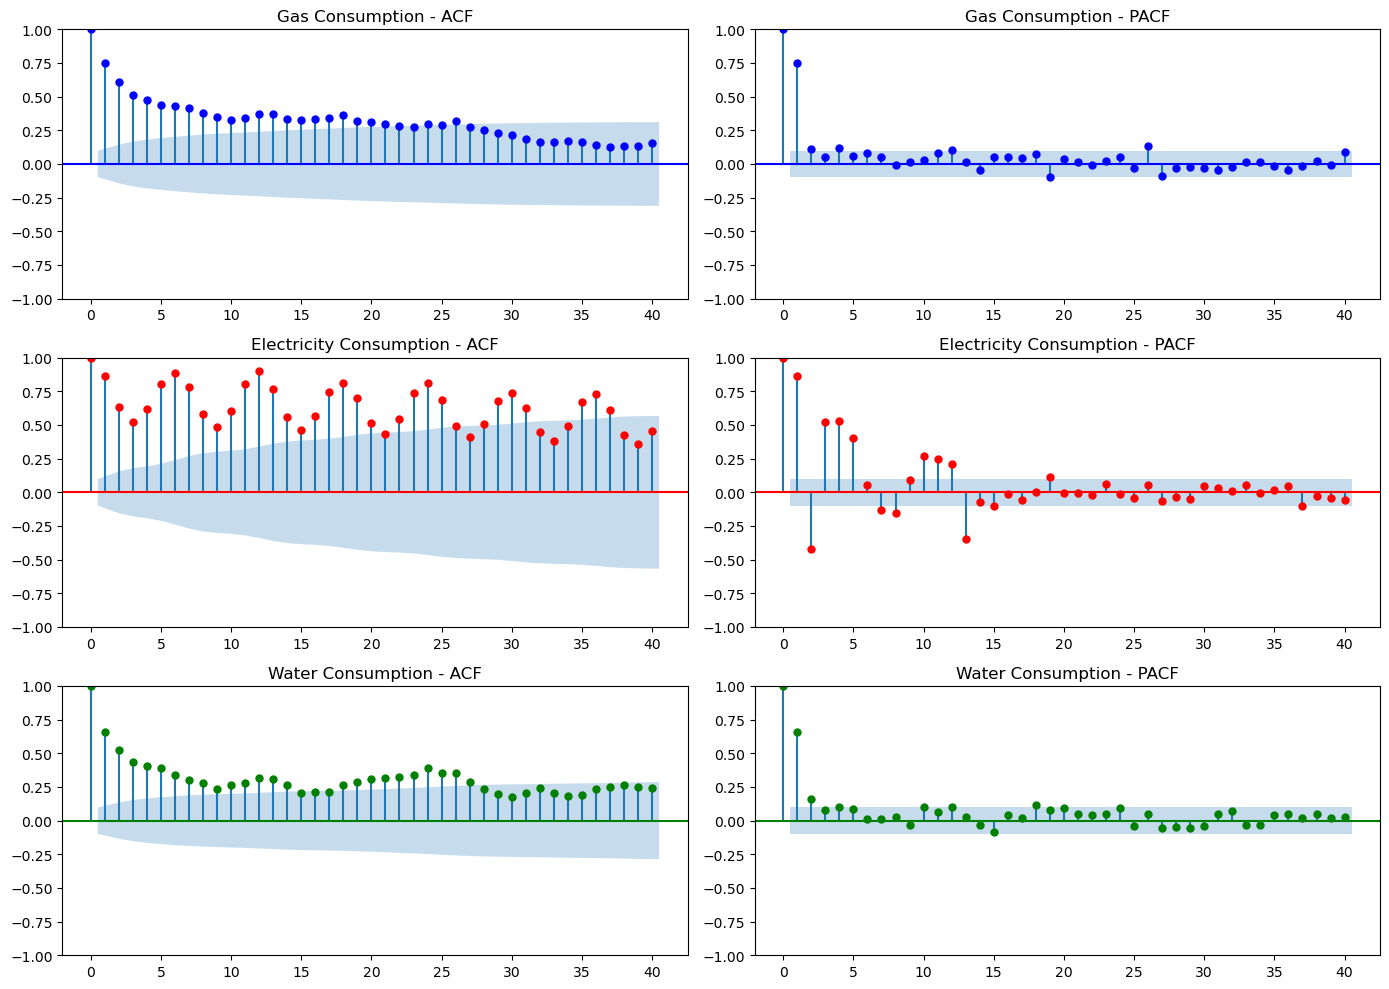

In [99]:
# ------------- Defining Time Series Variables ------------- #
time_series_variables = {
    "Gas Consumption": df["Gas Consumption (tons)"],
    "Electricity Consumption": df["Electricity Consumption (MWh)"],
    "Water Consumption": df["Water Consumption (tons)"]
}

# ------------- Colors For Each Variable ------------- #
colors = {"Gas Consumption": "blue", "Electricity Consumption": "red", "Water Consumption": "green"}

# ------------- Create ACF And PACF Plots ------------- #
fig, axes = plt.subplots(len(time_series_variables), 2, figsize=(14, 10))

for i, (label, series) in enumerate(time_series_variables.items()):
    # Plot ACF #
    sm.graphics.tsa.plot_acf(series, ax=axes[i, 0], lags=40, title=f"{label} - ACF", color=colors[label])
    
    # Plot PACF #
    sm.graphics.tsa.plot_pacf(series, ax=axes[i, 1], lags=40, title=f"{label} - PACF", color=colors[label], method="ywm")

# ------------- Displaying Plot ------------- #
plt.tight_layout()
plt.show()

# ------------- Compute ACF And PACF Values For First 10 Lags ------------- #
acf_pacf_results = {}

for label, series in time_series_variables.items():
    acf_values = acf(series, nlags=10)
    pacf_values = pacf(series, nlags=10, method="ywm")
    
    acf_pacf_results[label] = {
        "Lag": list(range(1, 11)),
        "ACF": acf_values[1:],
        "PACF": pacf_values[1:]
    }

# ------------- Converting To DataFrame ------------- #
acf_pacf_df = pd.DataFrame({
    "Lag": list(range(1, 11)),
    "Gas Consumption - ACF": acf_pacf_results["Gas Consumption"]["ACF"],
    "Gas Consumption - PACF": acf_pacf_results["Gas Consumption"]["PACF"],
    "Electricity Consumption - ACF": acf_pacf_results["Electricity Consumption"]["ACF"],
    "Electricity Consumption - PACF": acf_pacf_results["Electricity Consumption"]["PACF"],
    "Water Consumption - ACF": acf_pacf_results["Water Consumption"]["ACF"],
    "Water Consumption - PACF": acf_pacf_results["Water Consumption"]["PACF"],
})

<p>With reference to the output of the ACF and PACF plot above, I will be listing the observations below for each Variable.</p>
<br/>
<p><strong><u>Gas Consumption</u></strong></p>
<ul>
    <p><strong><u>Autocorrelation Function</u></strong></p>
    <li>Shows a gradual decay, meaning past values strongly influence future values.</li>
    <li>Suggests the presence of autoregressive (AR) components.</li>
    <li>Indicates that the series may need differencing to remove persistence.</li>
    <br/>
    <p><strong><u>Partial Autocorrelation Function</u></strong></p>
    <li>Sharp cutoff after lag 1, indicating a possible AR(1) process.</li>
    <li>Suggests that p = 1 for ARIMA modeling.</li>
</ul>
<p><strong><u>Electricity Consumption</u></strong></p>
<ul>
    <p><strong><u>Autocorrelation Function</u></strong></p>
    <li>Displays strong seasonal spikes at regular intervals.</li>
    <li>Suggests a seasonal pattern, requiring SARIMA modeling.</li>
    <li>Indicates the need for seasonal differencing.</li>
    <br/>
    <p><strong><u>Partial Autocorrelation Function</u></strong></p>
    <li>Significant spikes at multiple lags, suggesting multiple AR terms.</li>
    <li>Cutoff after lag 1 or 2, suggesting a combination of AR and MA terms.</li>
</ul>
<p><strong><u>Water Consumption</u></strong></p>
<ul>
    <p><strong><u>Autocorrelation Function</u></strong></p>
    <li>Gradual decay, suggesting a long-term correlation.</li>
    <li>Indicates that an AR process is needed.</li>
    <br/>
    <p><strong><u>Partial Autocorrelation Function</u></strong></p>
    <li>Sharp cutoff after lag 1, suggesting an AR(1) model.</li>
    <li>Suggests that p = 1 for ARIMA modeling.</li>
</ul>
<br/>
<p>With the observations and implications listed, I will be concluding the Autocorrelation Analysis.</p>

<hr/>
<h3>5.2.4 Ljung-Box Test</h3>

<p>The Ljung-Box Test is a statistical test used to check whether a time series has significant autocorrelation at different lags. It helps determine if the residuals of a model are white noise, meaning there is no predictable pattern left in the data. The Status Quo and Alternative Hypothesis is indicated below.</p>
<br/>
<ul>
    <li>H0 (Null Hypothesis): The residuals (or time series) are not autocorrelated.</li>
    <li>H1 (Alternative Hypothesis): The residuals (or time series) are autocorrelated.</li>
</ul>
<br/>
<p>With the hypothesis indicated, I will proceed to perform the Ljung-Box Test in the cell below.</p>

In [103]:
# ----------- Function To Perform Ljung-Box Test ----------- #
def ljung_box_test(series, label, lags=10):
    result = acorr_ljungbox(series.dropna(), lags=[lags], return_df=True)
    return {
        "Variable": label,
        "Lags": lags,
        "Test Statistic": result["lb_stat"].values[0],
        "p-value": f"{result['lb_pvalue'].values[0]:.2e}",
        "Autocorrelated": result["lb_pvalue"].values[0] < 0.05
    }

# ----------- First-Order Differencing ----------- #
df["Gas Consumption Diff"] = df["Gas Consumption (tons)"].diff().dropna()
df["Electricity Consumption Diff"] = df["Electricity Consumption (MWh)"].diff().dropna()
df["Water Consumption Diff"] = df["Water Consumption (tons)"].diff().dropna()

# ----------- Apply Ljung-Box Test On First-Order Differenced Data ----------- #
ljung_box_results_diff1 = {
    "Gas Consumption": ljung_box_test(df["Gas Consumption Diff"], "Gas Consumption"),
    "Electricity Consumption": ljung_box_test(df["Electricity Consumption Diff"], "Electricity Consumption"),
    "Water Consumption": ljung_box_test(df["Water Consumption Diff"], "Water Consumption"),
}

# ----------- Second-Order Differencing ----------- #
df["Gas Consumption Diff2"] = df["Gas Consumption Diff"].diff().dropna()
df["Electricity Consumption Diff2"] = df["Electricity Consumption Diff"].diff().dropna()
df["Water Consumption Diff2"] = df["Water Consumption Diff"].diff().dropna()

# ----------- Applying Ljung-Box Test On Second-Order Differenced Data ----------- #
ljung_box_results_diff2 = {
    "Gas Consumption": ljung_box_test(df["Gas Consumption Diff2"], "Gas Consumption"),
    "Electricity Consumption": ljung_box_test(df["Electricity Consumption Diff2"], "Electricity Consumption"),
    "Water Consumption": ljung_box_test(df["Water Consumption Diff2"], "Water Consumption"),
}

# ----------- Combine Results into a Single DataFrame ----------- #
ljung_box_comparison_df = pd.DataFrame({
    "Variable": ljung_box_results_diff1.keys(),
    "p-value (First Differencing)": [ljung_box_results_diff1[var]["p-value"] for var in ljung_box_results_diff1],
    "Autocorrelated (First Differencing)": [ljung_box_results_diff1[var]["Autocorrelated"] for var in ljung_box_results_diff1],
    "p-value (Second Differencing)": [ljung_box_results_diff2[var]["p-value"] for var in ljung_box_results_diff2],
    "Autocorrelated (Second Differencing)": [ljung_box_results_diff2[var]["Autocorrelated"] for var in ljung_box_results_diff2],
}).set_index("Variable")

# ----------- Clean Up Temporary Differenced Columns ----------- #
df.drop(["Gas Consumption Diff", "Electricity Consumption Diff", "Water Consumption Diff",
         "Gas Consumption Diff2", "Electricity Consumption Diff2", "Water Consumption Diff2"], axis=1, inplace=True)

# ----------- Displaying DataFrame ----------- #
ljung_box_comparison_df

,p-value (First Differencing),Autocorrelated (First Differencing),p-value (Second Differencing),Autocorrelated (Second Differencing)
Variable,,,,
Gas Consumption,2.23e-04,True,2.23e-23,True
Electricity Consumption,6.00e-244,True,5.18e-145,True
Water Consumption,4.95e-07,True,1.41e-27,True


<p>Since the p-values are still extremely low (< 0.05) after second-order differencing, H0 is rejected, meaning autocorrelation persists. Other operations such as seasonal differencing or a more complex transformation may need to be done.</p>